# 실습 6-2 : STUCCO (대조집합 학습)

#### **<실습 내용>**

1. 대조집합 학습 개요
- STUCCO 알고리즘 원리

2. STUCCO 기본 예제 (Process_Data)
- 데이터 전처리 (연속형 변수 범주화)
- 대조집합(cset) 도출 및 해석

3. Vibe Coding 실습 (통신사 고객 이탈 데이터)

## 분석 준비

### 주요 라이브러리 호출

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from stucco import ContrastSetLearner

import logging
from stucco import ContrastSetLearner  # 대조집합 학습(Contrast Set Learning)을 수행하는 STUCCO 알고리즘 구현체

logging.getLogger().setLevel(logging.WARNING)  # stucco.py의 상세 진행 로그 숨기기

---

## 1) 데이터 불러오기

In [2]:
data = pd.read_csv("dataset/day6-2_data.csv")
print("데이터 크기:", data.shape)
data.head()

데이터 크기: (596, 12)


,Prod_ID,M1,M2,P1,P2,P3,C1,C2,P4,P5,P6,Y
0,1001001,15,E,A,B,D,110.192,27.049,A,A,B,0
1,1001002,20,E,A,B,D,109.940,27.215,A,A,A,0
2,1001003,15,U,A,B,B,110.214,27.444,B,B,B,4
3,1001004,25,K,B,B,C,107.260,27.300,A,A,C,0
4,1001005,20,E,A,A,D,105.026,28.283,B,B,A,0


In [3]:
# 불량 기준 설정: 제품 1개당 불량 개수(Y)가 3개 이상이면 Fault, 아니면 Pass로 그룹 라벨 생성
data["Fail"] = ["Fault" if i >= 3 else "Pass" for i in data["Y"]]
data

,Prod_ID,M1,M2,P1,P2,P3,C1,C2,P4,P5,P6,Y,Fail
0,1001001,15,E,A,B,D,110.192,27.049,A,A,B,0,Pass
1,1001002,20,E,A,B,D,109.940,27.215,A,A,A,0,Pass
2,1001003,15,U,A,B,B,110.214,27.444,B,B,B,4,Fault
3,1001004,25,K,B,B,C,107.260,27.300,A,A,C,0,Pass
4,1001005,20,E,A,A,D,105.026,28.283,B,B,A,0,Pass
...,...,...,...,...,...,...,...,...,...,...,...,...,...
591,1001592,15,E,A,C,D,115.153,31.652,A,A,C,0,Pass
592,1001593,15,E,A,B,D,114.593,33.890,A,A,B,0,Pass
593,1001594,20,U,A,A,B,105.724,33.251,B,B,A,0,Pass
594,1001595,25,E,A,A,A,109.783,32.054,A,A,D,0,Pass


In [4]:
print("클래스 분포:")
print(data["Fail"].value_counts())

클래스 분포:
Fail
Pass     471
Fault    125
Name: count, dtype: int64


**활용할 반도체 공정 데이터 소개 (6-1과 동일)**

| 변수 | 설명 |
|---|---|
| Prod_ID | 제품 고유 ID |
| M1 | 공정 설비 온도 설정값 (15/20/25/30) |
| M2 | 사용 설비 ID (E, U, K) |
| P1 ~ P6 | 제품 설계/공정 옵션 (범주형 파라미터) |
| C1, C2 | 공정 중 측정된 연속형 값 |
| Y | 제품 1개당 발생한 불량 개수 |
| Fail | Y >= 3이면 Fault, 아니면 Pass로 정의한 라벨 |

## 2) 전처리하기

> STUCCO는 입력변수로 **범주형 변수만** 허용하므로 연속형 변수(C1, C2)는 구간화하여 범주형 변수 처럼 나타내야함

In [5]:
# 1. M1
# 숫자(15/20/25/30)로 저장되어 있음
# 그러나 실제로는 '온도 설정값'을 의미하는 범주이므로 범주형으로 변환
data["M1"] = data["M1"].astype("object")

# 2. 연속형 변수 C1, C2
# qcut: 데이터 개수가 균등하도록 4구간으로 분할
data["C1_cut"] = pd.qcut(data["C1"], 4)
# cut: 의미 있는 경계값 기준으로 직접 3구간 지정
data["C2_cut"] = pd.cut(data["C2"], bins=[18, 28, 32, 39], labels=["Low", "Normal", "High"]) 

### 2-1) STUCCO 실행

1. 비교할 그룹 설정
2. Contrast Set 후보 규칙 생성
3. 유의미한 규칙 추출

In [6]:
# STUCCO에 불필요한 변수 제거
# (ID, 이미 구간화한 원본 연속형 변수, 라벨 만드는 데 쓴 Y)
contra_data = data.drop(["Prod_ID", "C1", "C2", "Y"], axis=1)
contra_data

,M1,M2,P1,P2,P3,P4,P5,P6,Fail,C1_cut,C2_cut
0,15,E,A,B,D,A,A,B,Pass,"(109.191, 112.225]",Low
1,20,E,A,B,D,A,A,A,Pass,"(109.191, 112.225]",Low
2,15,U,A,B,B,B,B,B,Fault,"(109.191, 112.225]",Low
3,25,K,B,B,C,A,A,C,Pass,"(106.365, 109.191]",Low
4,20,E,A,A,D,B,B,A,Pass,"(102.158, 106.365]",Normal
...,...,...,...,...,...,...,...,...,...,...,...
591,15,E,A,C,D,A,A,C,Pass,"(112.225, 123.34]",Normal
592,15,E,A,B,D,A,A,B,Pass,"(112.225, 123.34]",High
593,20,U,A,A,B,B,B,A,Pass,"(102.158, 106.365]",High
594,25,E,A,A,A,A,A,D,Pass,"(109.191, 112.225]",High


> 1. 비교할 그룹 설정 (ContrastSetLearner())

In [7]:
# ContrastSetLearner(DataFrame, group_feature)

# "Fail" 컬럼의 그룹을 기준으로 Contrast Set 탐색
# Contrast Set: 그룹 간 차이를 가장 잘 설명하는 규칙

learner = ContrastSetLearner(contra_data, group_feature="Fail")
learner

> 2. Contrast Set 후보 규칙 생성 (learn())

In [8]:
# learner.learn():
# 그룹 간 차이를 설명할 수 있는 규칙 후보(조건 조합)를 생성
# 각 규칙의 그룹별 등장 빈도를 계산

# max_length: 규칙을 구성하는 최대 조건 수
# n_matrices: 규칙이 각 그룹에서 몇 번 나타났는지 등의 빈도 정보를 저장

n_matrices = learner.learn(max_length=3)
n_matrices

4217

> 3. 유의미한 규칙 추출 (score())

In [9]:
# learner.score():
# learn( )에서 생성한 빈도 정보를 활용해 규칙별 Support, Confidence, Lift를 계산

# Support: 규칙의 출현 비율
# Confidence: 규칙이 나타났을 때 해당 그룹일 확률
# Lift: 특정 그룹과의 연관성 정도

# lift가 2.0 이상인(특정 그룹과의 연관성 정도) 규칙만 채택
contrast_rules = learner.score(min_lift=2.0)
contrast_rules

,rule,group,lift
4,"(P1=>A, P3=>A, C2_cut=>High)",Fail=>Fault,2.666667
13,"(M2=>U, P2=>A, P3=>A)",Fail=>Fault,2.650104
7,"(M2=>K, P1=>A, P6=>D)",Fail=>Fault,2.625000
15,"(M1=>25, P1=>A, P3=>C)",Fail=>Fault,2.300000
14,"(M1=>25, P1=>A, C2_cut=>Low)",Fail=>Fault,2.300000
5,"(P1=>A, P6=>D, C1_cut=>(106.365, 109.191])",Fail=>Fault,2.258065
9,"(M2=>K, P1=>A, P2=>B)",Fail=>Fault,2.250000
10,"(P1=>A, P5=>B, C1_cut=>(112.225, 123.34])",Fail=>Fault,2.222222
8,"(P1=>A, P3=>D, P6=>D)",Fail=>Fault,2.181818
16,"(M1=>25, M2=>K, P1=>A)",Fail=>Fault,2.181818


In [10]:
# group 컬럼 값이 "Fail=>Fault", "Fail=>Pass" 형태로 저장되어 있음
# 보기 쉽게 "Fault", "Pass"만 남도록 문자열 변경
contrast_rules["group"] = contrast_rules["group"].str.replace("Fail=>", "")

# learn() 단계에서 생성된 전체 조건 조합(규칙 후보) 수 출력
print("생성된 조건 조합 수:", n_matrices)

# score() 단계의 기준을 통과하여 최종 선택된 Contrast Set 규칙 수 출력
print("도출된 규칙 수:", contrast_rules.shape[0])

생성된 조건 조합 수: 4217
도출된 규칙 수: 17


### 2-2) 결과 해석

In [11]:
# 도출된 규칙 확인
# 실제로는 Pass 규칙도 있었는데 score 기준에 따라 필터링 된 것임

contrast_rules.head()

,rule,group,lift
4,"(P1=>A, P3=>A, C2_cut=>High)",Fault,2.666667
13,"(M2=>U, P2=>A, P3=>A)",Fault,2.650104
7,"(M2=>K, P1=>A, P6=>D)",Fault,2.625000
15,"(M1=>25, P1=>A, P3=>C)",Fault,2.300000
14,"(M1=>25, P1=>A, C2_cut=>Low)",Fault,2.300000


In [12]:
# Fault 그룹을 설명하는 규칙만 추출
fault_rules = contrast_rules.loc[contrast_rules["group"] == "Fault"]

# Lift 기준 상위 5개 규칙 확인
fault_rules.sort_values(by="lift", ascending=False).head()

,rule,group,lift
4,"(P1=>A, P3=>A, C2_cut=>High)",Fault,2.666667
13,"(M2=>U, P2=>A, P3=>A)",Fault,2.650104
7,"(M2=>K, P1=>A, P6=>D)",Fault,2.625000
15,"(M1=>25, P1=>A, P3=>C)",Fault,2.300000
14,"(M1=>25, P1=>A, C2_cut=>Low)",Fault,2.300000


In [13]:
# Lift가 가장 높은 Contrast Set 규칙
# (P1=A) AND (P3=A) AND (C2_cut=High)를 만족하는 데이터 선택

cset_mask = (data["P1"] == "A") & (data["P3"] == "A") & (data["C2_cut"] == "High")

# 규칙을 만족하는 데이터의 불량(Fail) 분포 확인
print("cset 해당 데이터 불량 분포:")
print(data.loc[cset_mask, "Fail"].value_counts())
print()

# 규칙을 만족하지 않는 데이터의 불량(Fail) 분포 확인
print("cset 미해당 데이터 불량 분포:")
print(data.loc[~cset_mask, "Fail"].value_counts())

cset 해당 데이터 불량 분포:
Fail
Fault    12
Pass      6
Name: count, dtype: int64

cset 미해당 데이터 불량 분포:
Fail
Pass     465
Fault    113
Name: count, dtype: int64


---

## 3) Vibe Coding 실습 (통신사 고객 이탈 데이터)

STUCCO를 **통신사 고객 이탈(Customer Churn) 데이터셋**에 직접 적용해 봅니다.

- `dataset/day6_vibecoding.csv` 파일 사용하기
- 타겟 변수: `Churn` (No: 유지, Yes: 이탈)

In [14]:
# 필요한 라이브러리 호출하기
from sklearn.preprocessing import StandardScaler
from sklearn.impute import KNNImputer

# 0. 데이터 불러오기
data = pd.read_csv('dataset/day6_vibecoding.csv')

# 1. 결측치 처리
# 범주형(InternetService, PaymentMethod) → 최빈값 대치
for col in ['InternetService', 'PaymentMethod']:
    data[col] = data[col].fillna(data[col].mode()[0])

# TotalCharges → 중앙값 대치
data['TotalCharges'] = data['TotalCharges'].fillna(data['TotalCharges'].median())

# tenure, MonthlyCharges → KNN Imputer (비슷한 고객들의 값을 참고해 대치)
knn_cols = ['tenure', 'MonthlyCharges']
imputer = KNNImputer(n_neighbors=5)
data[knn_cols] = imputer.fit_transform(data[knn_cols])

# 2. 군집화에 쓰지 않을 컬럼 분리 
# Churn: 군집화 단계에서는 사용하지 않고, 군집 해석(군집별 이탈률 비교) 시에만 참고
churn = data['Churn']
X = data.drop(columns=['Churn'])

# 3. 수치형 변수 스케일링 
# K-Means/DBSCAN은 거리 기반이라 변수 스케일이 다르면 특정 변수가 거리 계산을 왜곡할 수 있음
numeric_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']
scaler = StandardScaler()
X[numeric_cols] = scaler.fit_transform(X[numeric_cols])

# 4. 범주형 변수 인코딩 
# 값이 2개뿐인 이진 범주형 변수는 0/1로 Label Encoding
binary_map = {
    'gender':           {'Male': 1, 'Female': 0},
    'Partner':          {'Yes': 1, 'No': 0},
    'Dependents':       {'Yes': 1, 'No': 0},
    'PhoneService':     {'Yes': 1, 'No': 0},
    'PaperlessBilling': {'Yes': 1, 'No': 0},
}
for col, mapping in binary_map.items():
    X[col] = X[col].map(mapping)

# 값이 3개 이상인 다중 범주형 변수는 One-Hot Encoding
ohe_cols = ['MultipleLines', 'InternetService', 'OnlineSecurity',
            'OnlineBackup', 'DeviceProtection', 'TechSupport',
            'StreamingTV', 'StreamingMovies', 'Contract', 'PaymentMethod']
X = pd.get_dummies(X, columns=ohe_cols, drop_first=True)

X.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,MultipleLines_No phone service,...,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,0,1,0,-1.287160,0,1,-1.175218,-0.994242,True,...,False,False,False,False,False,False,False,False,True,False
1,1,0,0,0,0.068195,1,0,-0.263952,-0.173244,False,...,False,False,False,False,False,True,False,False,False,True
2,1,0,0,0,-1.246088,1,1,-0.368193,-0.959674,False,...,False,False,False,False,False,False,False,False,False,True
3,1,0,0,0,0.519980,0,0,-0.756574,-0.194766,True,...,True,False,False,False,False,True,False,False,False,False
4,0,0,0,0,-1.246088,1,1,0.198407,-0.940470,False,...,False,False,False,False,False,False,False,False,True,False


**[과제]** 본 데이터셋에서의 연속형 범수인 'tenure', 'MonthlyCharges', 'TotalCharges'를 `pd.qcut` 등으로 구간화하고 `ContrastSetLearner`로 Churn(Yes/No) 그룹 간 대조집합을 도출하는 코드를 AI와 상의해서 작성하세요.

1 프로폼트

위의 과제를 수행할거야
1. pd.qcut 으로 세 연속형 변수에 대해 구간화를 진행한 후 시각화해줘.
2. 구간화를 한 data 를 기반으로 churn 의 yes / no 그룹 대조 집합을 도출하고, 각 집합의 score 를 정리해서 출력해줘.

=== qcut 구간화 확인 ===


,tenure,MonthlyCharges,TotalCharges,tenure_bin,MonthlyCharges_bin,TotalCharges_bin,Churn
0,1.0,29.85,29.85,Q1_Low,Q1_Low,Q1_Low,No
1,34.0,56.95,1889.50,Q3_MidHigh,Q2_MidLow,Q3_MidHigh,No
2,2.0,53.85,108.15,Q1_Low,Q2_MidLow,Q1_Low,Yes
3,45.0,42.30,1840.75,Q3_MidHigh,Q2_MidLow,Q3_MidHigh,No
4,2.0,70.70,151.65,Q1_Low,Q3_MidHigh,Q1_Low,Yes


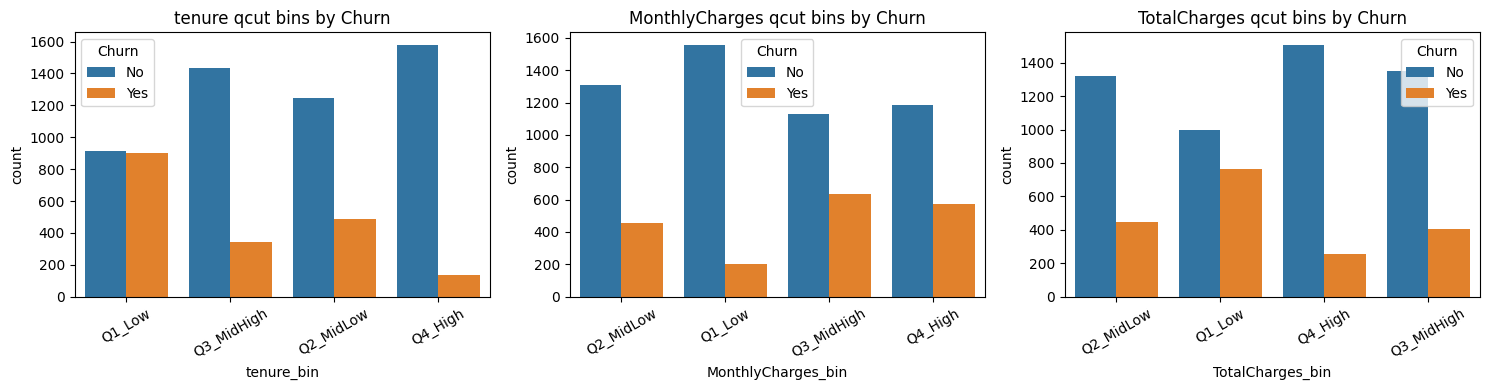

=== Contrast Set 결과 ===
생성된 조건 조합 수: 107
도출된 규칙 수: 16

=== 그룹별 score 요약(Yes/No) ===


,group,rules,mean_lift,max_lift
0,Yes,0,0.000000,0.000000
1,No,16,1.181143,1.360209


=== 그룹별 상위 규칙 (lift desc) ===


,rule,group,lift
9,"(tenure_bin=>Q3_MidHigh, MonthlyCharges_bin=>Q...",No,1.360209
2,"(MonthlyCharges_bin=>Q1_Low, TotalCharges_bin=...",No,1.289292
5,"(tenure_bin=>Q2_MidLow, MonthlyCharges_bin=>Q1...",No,1.268850
13,"(tenure_bin=>Q4_High, TotalCharges_bin=>Q4_High)",No,1.261720
12,"(tenure_bin=>Q4_High,)",No,1.254747
0,"(MonthlyCharges_bin=>Q1_Low,)",No,1.202767
7,"(MonthlyCharges_bin=>Q3_MidHigh, TotalCharges_...",No,1.202580
15,"(tenure_bin=>Q4_High, MonthlyCharges_bin=>Q4_H...",No,1.184760
14,"(tenure_bin=>Q4_High, MonthlyCharges_bin=>Q4_H...",No,1.180068
4,"(MonthlyCharges_bin=>Q2_MidLow, TotalCharges_b...",No,1.164627


In [16]:
# [1 프로폼트] qcut 구간화 + 시각화 + Churn 대조집합(Contrast Set) score 정리

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from stucco import ContrastSetLearner

# 연속형 3개 변수 구간화
cont_cols = ["tenure", "MonthlyCharges", "TotalCharges"]
labels = ["Q1_Low", "Q2_MidLow", "Q3_MidHigh", "Q4_High"]

vibe_data = data.copy()

for col in cont_cols:
    vibe_data[f"{col}_bin"] = pd.qcut(
        vibe_data[col], q=4, labels=labels, duplicates="drop"
    )

print("=== qcut 구간화 확인 ===")
display(vibe_data[[*cont_cols, "tenure_bin", "MonthlyCharges_bin", "TotalCharges_bin", "Churn"]].head())

# 1) 구간화 결과 시각화
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for i, col in enumerate(cont_cols):
    bin_col = f"{col}_bin"
    order = vibe_data[bin_col].astype(str).value_counts().index.tolist()
    sns.countplot(data=vibe_data, x=bin_col, hue="Churn", order=order, ax=axes[i])
    axes[i].set_title(f"{col} qcut bins by Churn")
    axes[i].tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.show()

# 2) 구간화 데이터 기반 Contrast Set 도출
#    (요구사항대로 qcut 결과를 중심으로 분석)
contra_data_vibe = vibe_data[["tenure_bin", "MonthlyCharges_bin", "TotalCharges_bin", "Churn"]].copy()

# STUCCO 입력 안정화를 위해 문자열화
for c in ["tenure_bin", "MonthlyCharges_bin", "TotalCharges_bin", "Churn"]:
    contra_data_vibe[c] = contra_data_vibe[c].astype(str)

learner_vibe = ContrastSetLearner(contra_data_vibe, group_feature="Churn")
n_matrices_vibe = learner_vibe.learn(max_length=3)
contrast_rules_vibe = learner_vibe.score(min_lift=1.2)

# 한쪽 그룹만 나오면(임계치가 높을 때) min_lift를 완화해 Yes/No 모두 확인
if contrast_rules_vibe["group"].nunique() < 2:
    contrast_rules_vibe = learner_vibe.score(min_lift=1.0)

# group 컬럼 보기 좋게 정리 (예: Churn=>Yes -> Yes)
contrast_rules_vibe["group"] = contrast_rules_vibe["group"].str.replace("Churn=>", "", regex=False)

print("=== Contrast Set 결과 ===")
print("생성된 조건 조합 수:", n_matrices_vibe)
print("도출된 규칙 수:", contrast_rules_vibe.shape[0])

# 각 집합(Yes/No) score 정리
score_summary = (
    contrast_rules_vibe.groupby("group")
    .agg(
        rules=("rule", "count"),
        mean_lift=("lift", "mean"),
        max_lift=("lift", "max"),
    )
    .reindex(["Yes", "No"], fill_value=0)
    .reset_index()
)

print("\n=== 그룹별 score 요약(Yes/No) ===")
display(score_summary)

print("=== 그룹별 상위 규칙 (lift desc) ===")
display(contrast_rules_vibe.sort_values(["group", "lift"], ascending=[True, False]))


1-1 프로폼트
1. qcut 의 구간 개수 k 를 2, 3, 4, 5 로 나누어서 수행한 후 k 별로 플롯해줘
2. k 간에 score 가 가장 높을 k 를 뽑아줘
3. 그 k 값을 기반으로 대조집합을 도출해줘


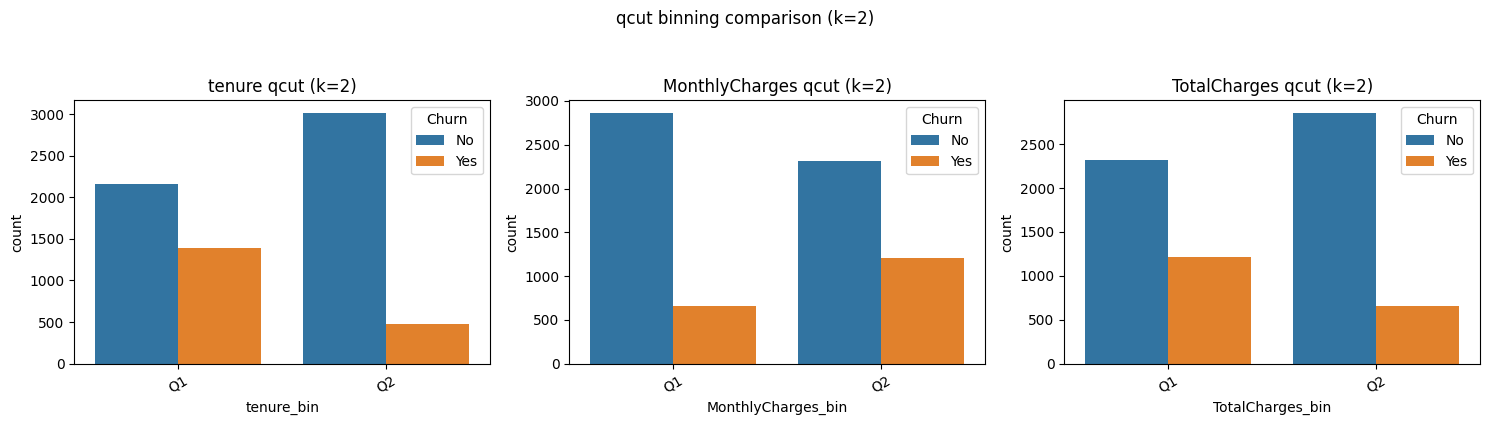

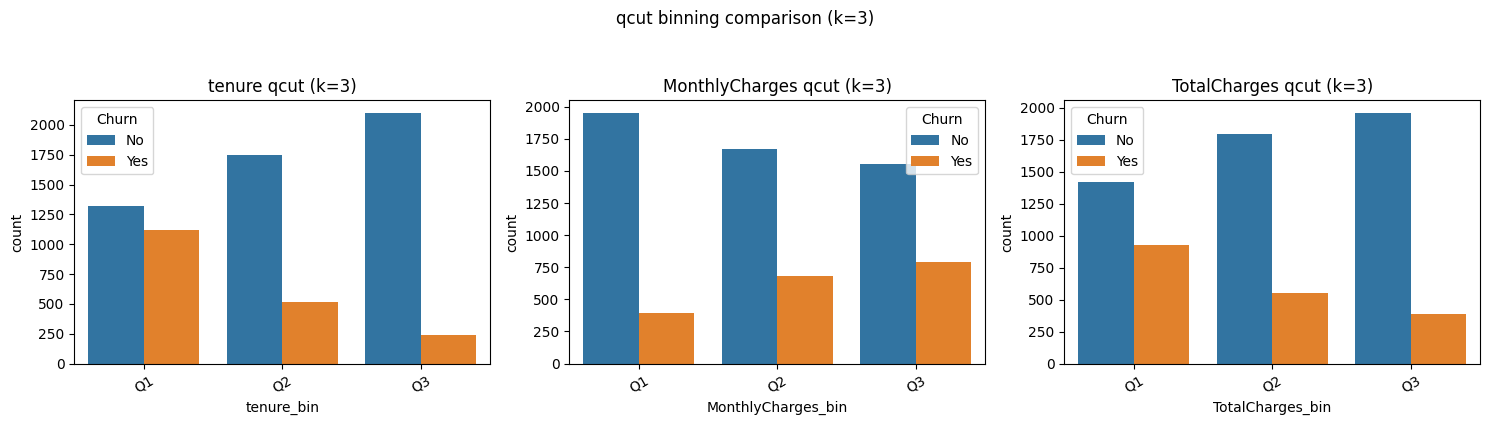

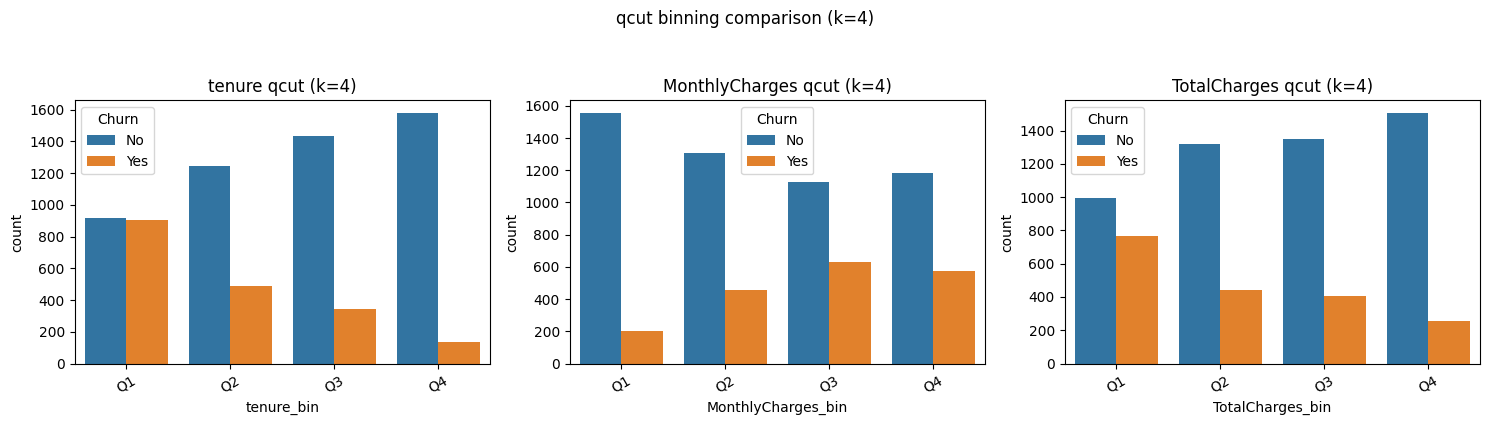

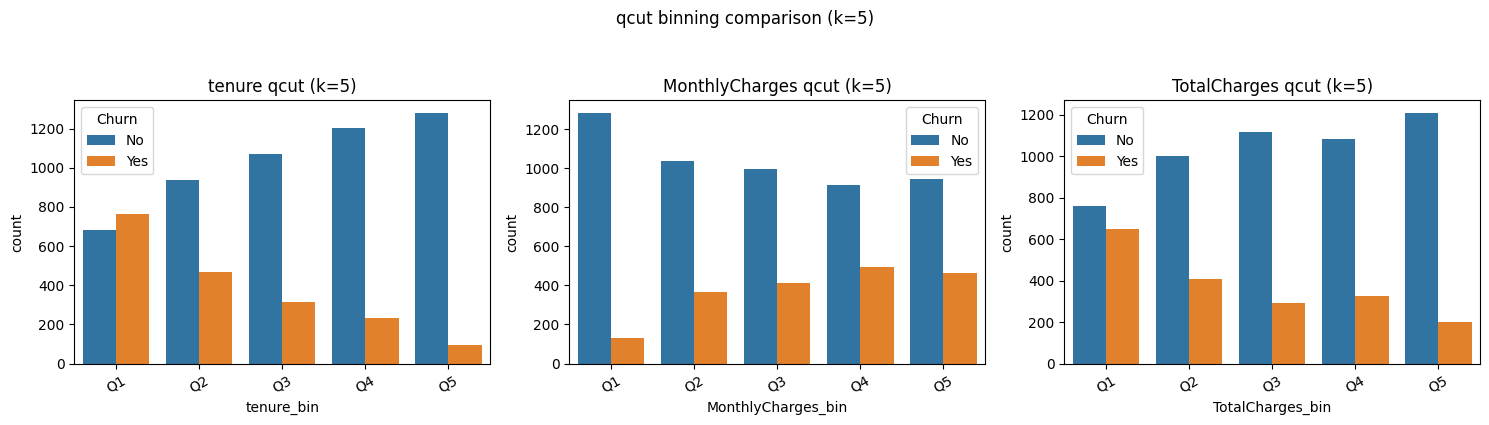

=== k별 Contrast Set score 비교 ===


,k,n_matrices,n_rules_total,n_rules_yes,n_rules_no,yes_max_lift,yes_mean_lift,no_max_lift
0,2,26,10,5,5,1.900035,1.775106,1.479658
1,3,62,23,0,23,0.000000,0.000000,1.551946
2,4,107,16,0,16,0.000000,0.000000,1.360209
3,5,170,9,0,9,0.000000,0.000000,1.269027



추천 k: 2 (Yes 그룹 lift/규칙수 기준)
=== best_k 전체 규칙 상위 ===


,rule,group,lift
0,"(tenure_bin=>Q1, MonthlyCharges_bin=>Q2, Total...",Yes,1.900035
1,"(tenure_bin=>Q1, MonthlyCharges_bin=>Q2)",Yes,1.789911
2,"(MonthlyCharges_bin=>Q2, TotalCharges_bin=>Q1)",Yes,1.765723
3,"(tenure_bin=>Q1, MonthlyCharges_bin=>Q2, Total...",Yes,1.731495
4,"(tenure_bin=>Q1, TotalCharges_bin=>Q2)",Yes,1.688367
5,"(tenure_bin=>Q2, MonthlyCharges_bin=>Q1, Total...",No,1.479658
6,"(MonthlyCharges_bin=>Q1, TotalCharges_bin=>Q2)",No,1.432727
7,"(tenure_bin=>Q2, MonthlyCharges_bin=>Q1)",No,1.379193
8,"(tenure_bin=>Q2, MonthlyCharges_bin=>Q1, Total...",No,1.228087
9,"(tenure_bin=>Q2, TotalCharges_bin=>Q1)",No,1.201752


=== best_k에서 Yes 규칙 상위 ===


,rule,group,lift
0,"(tenure_bin=>Q1, MonthlyCharges_bin=>Q2, Total...",Yes,1.900035
1,"(tenure_bin=>Q1, MonthlyCharges_bin=>Q2)",Yes,1.789911
2,"(MonthlyCharges_bin=>Q2, TotalCharges_bin=>Q1)",Yes,1.765723
3,"(tenure_bin=>Q1, MonthlyCharges_bin=>Q2, Total...",Yes,1.731495
4,"(tenure_bin=>Q1, TotalCharges_bin=>Q2)",Yes,1.688367


In [17]:
# [1-1 프로폼트] qcut 구간 개수 k=2,3,4,5 비교 + k별 Contrast Set score 비교

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from stucco import ContrastSetLearner

cont_cols = ["tenure", "MonthlyCharges", "TotalCharges"]
k_list = [2, 3, 4, 5]

# k별 시각화
for k in k_list:
    tmp = data.copy()

    # k개 구간 레이블 동적 생성
    labels = [f"Q{i+1}" for i in range(k)]

    for col in cont_cols:
        tmp[f"{col}_bin"] = pd.qcut(tmp[col], q=k, labels=labels, duplicates="drop")

    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    for i, col in enumerate(cont_cols):
        bcol = f"{col}_bin"
        sns.countplot(data=tmp, x=bcol, hue="Churn", ax=axes[i])
        axes[i].set_title(f"{col} qcut (k={k})")
        axes[i].tick_params(axis="x", rotation=30)
    plt.suptitle(f"qcut binning comparison (k={k})", y=1.05)
    plt.tight_layout()
    plt.show()

# k별 Contrast Set score 비교
rows = []
all_rules_by_k = {}

for k in k_list:
    tmp = data.copy()
    labels = [f"Q{i+1}" for i in range(k)]

    for col in cont_cols:
        tmp[f"{col}_bin"] = pd.qcut(tmp[col], q=k, labels=labels, duplicates="drop")

    contra = tmp[["tenure_bin", "MonthlyCharges_bin", "TotalCharges_bin", "Churn"]].copy()
    for c in contra.columns:
        contra[c] = contra[c].astype(str)

    learner_k = ContrastSetLearner(contra, group_feature="Churn")
    n_matrices_k = learner_k.learn(max_length=3)

    # 기본 threshold -> 한쪽 그룹만 나오면 완화
    rules_k = learner_k.score(min_lift=1.2)
    if rules_k["group"].nunique() < 2:
        rules_k = learner_k.score(min_lift=1.0)

    rules_k["group"] = rules_k["group"].str.replace("Churn=>", "", regex=False)
    all_rules_by_k[k] = rules_k.copy()

    yes_rules = rules_k[rules_k["group"] == "Yes"]
    no_rules = rules_k[rules_k["group"] == "No"]

    rows.append({
        "k": k,
        "n_matrices": int(n_matrices_k),
        "n_rules_total": int(rules_k.shape[0]),
        "n_rules_yes": int(yes_rules.shape[0]),
        "n_rules_no": int(no_rules.shape[0]),
        "yes_max_lift": float(yes_rules["lift"].max()) if len(yes_rules) else 0.0,
        "yes_mean_lift": float(yes_rules["lift"].mean()) if len(yes_rules) else 0.0,
        "no_max_lift": float(no_rules["lift"].max()) if len(no_rules) else 0.0,
    })

k_compare_df = pd.DataFrame(rows).sort_values(["yes_max_lift", "yes_mean_lift", "n_rules_yes"], ascending=False).reset_index(drop=True)

print("=== k별 Contrast Set score 비교 ===")
display(k_compare_df)

best_k = int(k_compare_df.loc[0, "k"])
best_rules = all_rules_by_k[best_k].sort_values("lift", ascending=False).reset_index(drop=True)

print(f"\n추천 k: {best_k} (Yes 그룹 lift/규칙수 기준)")
print("=== best_k 전체 규칙 상위 ===")
display(best_rules.head(20))

print("=== best_k에서 Yes 규칙 상위 ===")
display(best_rules[best_rules["group"] == "Yes"].head(10))

**[과제]** 도출된 규칙 중 이탈(Yes) 그룹에서 lift가 높은 상위 규칙들을 확인하고 어떤 조건 조합이 이탈과 강하게 연관되는지 AI와 함께 해석해 보세요.

2-1 프로폼트
1. 앞에서 도출한 대조집합의 규칙을 기반으로 어떤 조건 조합이 이탈에 강하게 연관되는지 순위별로 출력해줘.
2. 각각 출력의 결과의 의미를 해석해서 한 줄로 요약해줘.

In [18]:
# [2-1 프로폼트] 이탈(Yes) 연관 규칙 순위 출력 + 한 줄 해석

# 1) 앞 셀 결과 재사용 (없으면 안전하게 재계산)
if "best_k" not in globals() or "all_rules_by_k" not in globals():
    cont_cols = ["tenure", "MonthlyCharges", "TotalCharges"]
    k_list = [2, 3, 4, 5]

    all_rules_by_k = {}
    rows = []

    for k in k_list:
        tmp = data.copy()
        labels = [f"Q{i+1}" for i in range(k)]

        for col in cont_cols:
            tmp[f"{col}_bin"] = pd.qcut(tmp[col], q=k, labels=labels, duplicates="drop")

        contra = tmp[["tenure_bin", "MonthlyCharges_bin", "TotalCharges_bin", "Churn"]].copy()
        for c in contra.columns:
            contra[c] = contra[c].astype(str)

        learner_k = ContrastSetLearner(contra, group_feature="Churn")
        learner_k.learn(max_length=3)
        rules_k = learner_k.score(min_lift=1.2)
        if rules_k["group"].nunique() < 2:
            rules_k = learner_k.score(min_lift=1.0)

        rules_k["group"] = rules_k["group"].str.replace("Churn=>", "", regex=False)
        all_rules_by_k[k] = rules_k.copy()

        yes_rules = rules_k[rules_k["group"] == "Yes"]
        rows.append({
            "k": k,
            "n_rules_yes": len(yes_rules),
            "yes_max_lift": float(yes_rules["lift"].max()) if len(yes_rules) else 0.0,
        })

    tmp_df = pd.DataFrame(rows).sort_values(["yes_max_lift", "n_rules_yes"], ascending=False)
    best_k = int(tmp_df.iloc[0]["k"])

# 2) 선택된 k에서 Yes 규칙 순위
rules_best = all_rules_by_k[best_k].copy()
yes_rules_ranked = rules_best[rules_best["group"] == "Yes"].sort_values("lift", ascending=False).reset_index(drop=True)

print(f"=== 선택된 k: {best_k} ===")
print("=== 이탈(Yes) 연관 규칙 순위 (lift 내림차순) ===")

if yes_rules_ranked.empty:
    print("Yes 규칙이 도출되지 않았습니다. (현재 설정에서 No 규칙이 우세)")
else:
    display(yes_rules_ranked)

    # 3) 각 결과의 의미를 한 줄 요약
    summary_rows = []
    for i, row in yes_rules_ranked.iterrows():
        one_line = (
            f"Rank {i+1}: {row['rule']} 조건은 Churn=Yes와 연관성이 높으며 "
            f"(lift={row['lift']:.3f}), 전체 대비 이탈 발생 비중이 상대적으로 크게 나타난다."
        )
        summary_rows.append({
            "rank": i + 1,
            "rule": str(row["rule"]),
            "lift": float(row["lift"]),
            "one_line_summary": one_line,
        })

    summary_df = pd.DataFrame(summary_rows)

    print("=== 규칙별 한 줄 해석 ===")
    display(summary_df)

    # 상위 3개만 별도 출력
    print("\n=== Top 3 한 줄 요약 ===")
    for _, r in summary_df.head(3).iterrows():
        print("-", r["one_line_summary"])

=== 선택된 k: 2 ===
=== 이탈(Yes) 연관 규칙 순위 (lift 내림차순) ===


,rule,group,lift
0,"(tenure_bin=>Q1, MonthlyCharges_bin=>Q2, Total...",Yes,1.900035
1,"(tenure_bin=>Q1, MonthlyCharges_bin=>Q2)",Yes,1.789911
2,"(MonthlyCharges_bin=>Q2, TotalCharges_bin=>Q1)",Yes,1.765723
3,"(tenure_bin=>Q1, MonthlyCharges_bin=>Q2, Total...",Yes,1.731495
4,"(tenure_bin=>Q1, TotalCharges_bin=>Q2)",Yes,1.688367


=== 규칙별 한 줄 해석 ===


,rank,rule,lift,one_line_summary
0,1,"('tenure_bin=>Q1', 'MonthlyCharges_bin=>Q2', '...",1.900035,"Rank 1: ('tenure_bin=>Q1', 'MonthlyCharges_bin..."
1,2,"('tenure_bin=>Q1', 'MonthlyCharges_bin=>Q2')",1.789911,"Rank 2: ('tenure_bin=>Q1', 'MonthlyCharges_bin..."
2,3,"('MonthlyCharges_bin=>Q2', 'TotalCharges_bin=>...",1.765723,"Rank 3: ('MonthlyCharges_bin=>Q2', 'TotalCharg..."
3,4,"('tenure_bin=>Q1', 'MonthlyCharges_bin=>Q2', '...",1.731495,"Rank 4: ('tenure_bin=>Q1', 'MonthlyCharges_bin..."
4,5,"('tenure_bin=>Q1', 'TotalCharges_bin=>Q2')",1.688367,"Rank 5: ('tenure_bin=>Q1', 'TotalCharges_bin=>..."



=== Top 3 한 줄 요약 ===
- Rank 1: ('tenure_bin=>Q1', 'MonthlyCharges_bin=>Q2', 'TotalCharges_bin=>Q2') 조건은 Churn=Yes와 연관성이 높으며 (lift=1.900), 전체 대비 이탈 발생 비중이 상대적으로 크게 나타난다.
- Rank 2: ('tenure_bin=>Q1', 'MonthlyCharges_bin=>Q2') 조건은 Churn=Yes와 연관성이 높으며 (lift=1.790), 전체 대비 이탈 발생 비중이 상대적으로 크게 나타난다.
- Rank 3: ('MonthlyCharges_bin=>Q2', 'TotalCharges_bin=>Q1') 조건은 Churn=Yes와 연관성이 높으며 (lift=1.766), 전체 대비 이탈 발생 비중이 상대적으로 크게 나타난다.


**[과제]** 가장 중요한 규칙에 해당하는 고객들의 실제 이탈률을 비교해서 해당 규칙이 실제로 유의미한지 검증해 보세요.

In [ ]:
# [3-1] 가장 중요한 규칙의 실제 이탈률 검증

import numpy as np
import pandas as pd
from scipy.stats import chi2_contingency

# 1) 규칙 준비 (앞 셀 결과 재사용, 없으면 안전하게 재계산)
if "best_k" not in globals() or "all_rules_by_k" not in globals():
    cont_cols = ["tenure", "MonthlyCharges", "TotalCharges"]
    k_list = [2, 3, 4, 5]
    all_rules_by_k = {}

    rows = []
    for k in k_list:
        tmp = data.copy()
        labels = [f"Q{i+1}" for i in range(k)]
        for col in cont_cols:
            tmp[f"{col}_bin"] = pd.qcut(tmp[col], q=k, labels=labels, duplicates="drop")

        contra = tmp[["tenure_bin", "MonthlyCharges_bin", "TotalCharges_bin", "Churn"]].copy()
        for c in contra.columns:
            contra[c] = contra[c].astype(str)

        learner_k = ContrastSetLearner(contra, group_feature="Churn")
        learner_k.learn(max_length=3)
        rules_k = learner_k.score(min_lift=1.2)
        if rules_k["group"].nunique() < 2:
            rules_k = learner_k.score(min_lift=1.0)

        rules_k["group"] = rules_k["group"].str.replace("Churn=>", "", regex=False)
        all_rules_by_k[k] = rules_k

        yes_rules = rules_k[rules_k["group"] == "Yes"]
        rows.append({
            "k": k,
            "n_rules_yes": len(yes_rules),
            "yes_max_lift": float(yes_rules["lift"].max()) if len(yes_rules) else 0.0,
        })

    best_k = int(pd.DataFrame(rows).sort_values(["yes_max_lift", "n_rules_yes"], ascending=False).iloc[0]["k"])

rules_best = all_rules_by_k[best_k].copy()
yes_rules_ranked = rules_best[rules_best["group"] == "Yes"].sort_values("lift", ascending=False).reset_index(drop=True)

if yes_rules_ranked.empty:
    target_rule = rules_best.sort_values("lift", ascending=False).iloc[0]["rule"]
    target_group = rules_best.sort_values("lift", ascending=False).iloc[0]["group"]
else:
    target_rule = yes_rules_ranked.iloc[0]["rule"]
    target_group = "Yes"

print(f"=== 검증 대상 규칙 (k={best_k}) ===")
print("rule:", target_rule)
print("target_group:", target_group)

# 2) 원본 데이터에 동일 구간화 적용
verify_df = data.copy()
labels = [f"Q{i+1}" for i in range(best_k)]
for col in ["tenure", "MonthlyCharges", "TotalCharges"]:
    verify_df[f"{col}_bin"] = pd.qcut(verify_df[col], q=best_k, labels=labels, duplicates="drop")

# 3) rule 파싱 및 마스크 생성
# 예: ('tenure_bin=>Q1', 'MonthlyCharges_bin=>Q2', 'TotalCharges_bin=>Q2')
rule_items = [str(x) for x in tuple(target_rule)]
mask = pd.Series(True, index=verify_df.index)
for item in rule_items:
    left, right = item.split("=>", 1)
    mask &= (verify_df[left].astype(str) == right)

# 4) 실제 이탈률 비교
in_group = verify_df.loc[mask]
out_group = verify_df.loc[~mask]

rate_in = (in_group["Churn"] == "Yes").mean() if len(in_group) else np.nan
rate_out = (out_group["Churn"] == "Yes").mean() if len(out_group) else np.nan
rate_all = (verify_df["Churn"] == "Yes").mean()

result_df = pd.DataFrame({
    "Group": ["Rule matched", "Rule not matched", "Overall"],
    "N": [len(in_group), len(out_group), len(verify_df)],
    "ChurnYes_rate": [rate_in, rate_out, rate_all],
})

print("\n=== 실제 이탈률 비교 ===")
display(result_df)

# 5) 유의성 검정 (카이제곱)
# 행: 규칙 만족/비만족, 열: Yes/No
contingency = pd.crosstab(mask, verify_df["Churn"])
# 열 순서 보정
for col in ["Yes", "No"]:
    if col not in contingency.columns:
        contingency[col] = 0
contingency = contingency[["Yes", "No"]]

chi2, p_value, _, _ = chi2_contingency(contingency)
print("=== 카이제곱 검정 ===")
print("chi2:", round(chi2, 4), "| p-value:", p_value)

if p_value < 0.05:
    sig_msg = "통계적으로 유의미함 (p < 0.05)"
else:
    sig_msg = "통계적으로 유의미하다고 보기 어려움 (p >= 0.05)"

# 6) 한 줄 결론
print("\n=== 결론 ===")
print(
    f"규칙 만족 고객의 실제 이탈률은 {rate_in:.3f}, 비만족 고객은 {rate_out:.3f}이며, "
    f"해당 차이는 {sig_msg}."
)